# Zadanie 1. Wczytywanie i walidacja danych
Wczytaj dane z analizy NGS próbek środowiskowych, obejmują pliki:
* `data/environmental/samples.csv` - tabela z próbkami i ich metadanymi,
* `data/environmental/sites.csv` - tabela z opisem stanowisk,
* `data/environmental/sequences.csv` - tabela zawierająca sekwencje, które udało się zidentyfikować podczas sekwencjonowania,
* `data/environmental/biom.csv` - tabela zawiera liczbę wystąpień danej sekwencji w danej próbce,
* `data/environmental/taxonomy.csv` - tabela z identyfikacją taksonomiczną każdej sekwencji ,
* `data/environmental/taxa_db.csv` - tabela przechowująca nazwy taksonów.

Zapoznaj się z bazą danych i narysuj jej schemat z oznaczeniem połączeń między tabelami.

Oczyść dane z wartości brakujących i błędnych danych.

In [1]:
import pandas as pd

In [2]:
samples = pd.read_csv("data/environmental/samples.csv")
sites = pd.read_csv("data/environmental/sites.csv")
seq = pd.read_csv("data/environmental/sequences.csv")
biom = pd.read_csv("data/environmental/biom.csv")
taxonomy = pd.read_csv("data/environmental/taxonomy.csv")
tax_name = pd.read_csv("data/environmental/taxa_db.csv")


/tmp/ipykernel_43185/2021949116.py:4: DtypeWarning: Columns (0: 472d6c64d9d6633b8c7f4274920e0cde, 1: 6f204260468164ceb0e1d91f85402c04, 2: 739ada9f31394fcf327418d8f280129e, 3: 3e10b8b318edd2f617fd15e457f49235, 4: 73fac5248ad262fb38745224496bd195, 5: 3a5cc8e9b107a5eaed65ba1e2ce669b2, 6: 36e2c62b8cd2e888684654579d068bbe, 7: 3967d6567f6c61251d25d8447aeaea57, 8: 4fae68d9518c4b0bbc18dfb7c0cfbeb4, 9: 22e216e70b9fa7561a30c8f571222b58, 10: 064fa82e8050ac315318c8f558c35fb6, 11: deee2bb1e0305d2ecfd55542f2934125, 12: 1d16dcaa0a452eb436741e2e67169d21, 13: 5dadfdaeed7424af8f551d4e5cc607bc, 14: e19f1ae5606d8bb22254cf86aa6bd6ec, 15: 3237d77e6efcf7970e4b1edaf8184c87, 16: 2a978407835f6a0477e4e6200e4775c6, 17: 1e9af98c27e6af70d546802f830381a7, 18: ef4a7352931cc2f25f7f6af594fcc19b, 19: d94e0a77869f314e25619a4d455f64d7, 20: 319b12de3affc7e857788bd31e2fa2b3, 21: 540d71832489fd0940a54396a15ce1e4, 22: 98f620d1944f2a859e35ce47ae77ec19, 23: 28ad22b5898c86e508c90f959631cb61, 24: cfac33b5f31c388f6f4293bcfac228a3,

In [3]:
biom = biom.map(lambda x: 0 if not isinstance(x,int) else x)

In [4]:
samples.head()

,sample_id,site,season,depth,molecule,rep_number,temperature,humidity,particles,comment
0,1,site_1,spring,20.0,DNA,1.0,13.0,48.0,487.171474,NaN
1,2,site_1,spring,20.0,RNA,1.0,13.0,48.0,561.125523,NaN
2,3,site_1,spring,50.0,DNA,1.0,13.0,48.0,315.156923,NaN
3,4,site_1,spring,50.0,RNA,1.0,13.0,48.0,-69.196973,NaN
4,5,site_1,spring,80.0,DNA,1.0,13.0,48.0,282.204666,NaN


In [5]:
samples.describe()

,sample_id,depth,rep_number,temperature,humidity,particles
count,1530.00000,1530.000000,1530.000000,1530.000000,1530.000000,1530.000000
mean,765.50000,50.000000,3.000000,17.050980,57.450980,505.885507
std,441.81727,24.502906,1.414676,8.552612,30.626367,306.364822
min,1.00000,20.000000,1.000000,-4.000000,-23.000000,-389.823063
25%,383.25000,20.000000,2.000000,12.000000,31.000000,300.558213
50%,765.50000,50.000000,3.000000,16.000000,59.000000,513.326602
75%,1147.75000,80.000000,4.000000,22.000000,81.000000,713.012527
max,1530.00000,80.000000,5.000000,44.000000,129.000000,1554.307888


In [6]:
samples.info()

<class 'pandas.DataFrame'>
RangeIndex: 1530 entries, 0 to 1529
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sample_id    1530 non-null   int64  
 1   site         1530 non-null   str    
 2   season       1530 non-null   str    
 3   depth        1530 non-null   float64
 4   molecule     1530 non-null   str    
 5   rep_number   1530 non-null   float64
 6   temperature  1530 non-null   float64
 7   humidity     1530 non-null   float64
 8   particles    1530 non-null   float64
 9   comment      16 non-null     str    
dtypes: float64(5), int64(1), str(4)
memory usage: 119.7 KB


In [7]:
samples.isna().sum()

sample_id         0
site              0
season            0
depth             0
molecule          0
rep_number        0
temperature       0
humidity          0
particles         0
comment        1514
dtype: int64

In [8]:
samples.drop(columns="comment", inplace=True)

In [9]:
samples.isna().sum().sum()

np.int64(0)

In [10]:
samples.info() #rep_num moze byc int, nie float

<class 'pandas.DataFrame'>
RangeIndex: 1530 entries, 0 to 1529
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sample_id    1530 non-null   int64  
 1   site         1530 non-null   str    
 2   season       1530 non-null   str    
 3   depth        1530 non-null   float64
 4   molecule     1530 non-null   str    
 5   rep_number   1530 non-null   float64
 6   temperature  1530 non-null   float64
 7   humidity     1530 non-null   float64
 8   particles    1530 non-null   float64
dtypes: float64(5), int64(1), str(3)
memory usage: 107.7 KB


In [11]:
samples["rep_number"] = samples["rep_number"].astype(int)

In [12]:
samples["particles"].nlargest() #oki

659    1554.307888
638    1404.383603
723    1386.111090
49     1377.334232
919    1356.735821
Name: particles, dtype: float64

In [13]:
samples["temperature"].nsmallest() #wartosci minusowe w humidity i particles

714   -4.0
715   -4.0
716   -4.0
717   -4.0
718   -4.0
Name: temperature, dtype: float64

In [14]:
samples = samples[samples["particles"] >= 0]
samples = samples[samples["humidity"] >= 0]

In [15]:
samples = samples.reset_index(drop=True)

In [16]:
samples.info()

<class 'pandas.DataFrame'>
RangeIndex: 1433 entries, 0 to 1432
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sample_id    1433 non-null   int64  
 1   site         1433 non-null   str    
 2   season       1433 non-null   str    
 3   depth        1433 non-null   float64
 4   molecule     1433 non-null   str    
 5   rep_number   1433 non-null   int64  
 6   temperature  1433 non-null   float64
 7   humidity     1433 non-null   float64
 8   particles    1433 non-null   float64
dtypes: float64(4), int64(2), str(3)
memory usage: 100.9 KB


In [17]:
sites.head()

,site_name,latitude,longitude,human_activity,comment
0,site_1,52.044225,18.228474,urban,NaN
1,site_2,52.913425,20.542271,urban,NaN
2,site_3,52.816902,22.739079,rural,NaN
3,site_4,51.605502,20.886346,rural,NaN
4,site_5,50.312115,15.493592,urban,NaN


In [18]:
sites.isna().sum()

site_name          0
latitude           0
longitude          0
human_activity     0
comment           14
dtype: int64

In [19]:
sites.drop(columns="comment", inplace=True)

In [20]:
sites.isna().sum().sum()

np.int64(0)

In [21]:
sites.info() #typy sie zgadzaja

<class 'pandas.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   site_name       17 non-null     str    
 1   latitude        17 non-null     float64
 2   longitude       17 non-null     float64
 3   human_activity  17 non-null     str    
dtypes: float64(2), str(2)
memory usage: 676.0 bytes


In [22]:
sites["latitude"].nsmallest() #oki
sites["latitude"].nlargest() #oki

12    53.039363
1     52.913425
2     52.816902
14    52.460658
13    52.088223
Name: latitude, dtype: float64

In [23]:
sites["longitude"].nsmallest() #oki
sites["longitude"].nlargest() #oki

2     22.739079
11    22.659155
14    22.477409
9     21.901493
13    21.528566
Name: longitude, dtype: float64

In [24]:
seq.head()

,hash_id,sequence
0,b255348cc1e58c1f5e4f77575baff0b7,CCTGGACGCCCAACTCAACGCACCGGTACCCCGCCTCAGTCACCGT...
1,bd8b3a47b246b301d96b918a1a177c5d,GCGGATAAGGAGCCACAAGGTATAACTCCGGGCTATACTGTGTTTG...
2,aaa2ff7e3f3a1c4e96b874fd187224d8,CACCCCGATAGGAAATGTTTAAGCCATCTCCTGTCAATCTCCGCAG...
3,7c1d0d1f3aa16fdd80b83c100970cd8f,CTCCCTCATAATGTCCCATTGTGCATAGAGGCAGTGTGGAAGACCC...
4,335b27c09a71748015396455c7895118,CTCAGTGTTCTTATCGGATGGGCAAGTCTTCTGATCGAAGTGCGGG...


In [25]:
seq.isna().sum()

hash_id     0
sequence    0
dtype: int64

In [26]:
seq.info()

<class 'pandas.DataFrame'>
RangeIndex: 5372 entries, 0 to 5371
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   hash_id   5372 non-null   str  
 1   sequence  5372 non-null   str  
dtypes: str(2)
memory usage: 84.1 KB


In [27]:
seq.nunique()

hash_id     5372
sequence    5372
dtype: int64

In [28]:
biom.head(10)

,Unnamed: 0,cd2f6ab0a17fb7ba634b66b75cfb32dc,e2d7606d4577d12f4d8daba49614ef51,795a06e26ee8d33cacf68eda9a7b0534,c70d7b3cb1972d94e2f78784d354d014,87bb0d2a13ff63b63d48f4464ee163a1,191eed68aac33db853c135d04e477c4f,4cdfd0688d020ddf522f55de2e648b6b,7b42b469b645284a8b0b88c735c606c8,d833d4edf8e04229bf6f39a320a1dd28,...,f686fe0d561f270e73d34a1cc6403a4d,687cd976133673134b799c0f415daf7d,4863dd6c1012a17f995427a2f3ca16e0,c03eecbb5bff231f932c1776212e5c2a,bdf885b8c690bf0e56ab18c81460d3e6,7f827b7768ecc3bcd9f5de3f24b15822,df4531eb186e5209634f1a2d0645eab7,08097023ccb33df42438584599e69608,9a1511e0754f9cd78c10c1925a5e3a60,f62f0ecdc289778e5f625294bee9e118
0,1,92,1,76,65,20,22,67,60,31,...,0,0,0,0,0,0,0,0,0,0
1,2,96,108,183,244,71,0,0,196,165,...,0,0,0,0,0,0,0,0,0,0
2,3,35,59,225,90,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,126,0,83,0,0,15,62,246,80,...,0,0,0,0,0,0,0,0,0,0
4,5,170,229,368,213,171,41,1,17,122,...,0,0,0,0,0,0,0,0,0,0
5,6,0,0,46,27,219,1,39,71,49,...,0,0,0,0,0,0,0,0,0,0
6,7,10,53,37,262,55,159,296,1,220,...,0,0,0,0,0,0,0,0,0,0
7,8,32,0,12,375,0,23,145,199,0,...,0,0,0,0,0,0,0,0,0,0
8,9,0,221,1,0,321,170,120,1,1,...,0,0,0,0,0,0,0,0,0,0
9,10,151,76,31,74,63,164,104,0,328,...,0,0,0,0,0,0,0,0,0,0


In [29]:
biom.rename(columns={"Unnamed: 0": "indexy"}, inplace=True)

In [30]:
biom.head(20)

,indexy,cd2f6ab0a17fb7ba634b66b75cfb32dc,e2d7606d4577d12f4d8daba49614ef51,795a06e26ee8d33cacf68eda9a7b0534,c70d7b3cb1972d94e2f78784d354d014,87bb0d2a13ff63b63d48f4464ee163a1,191eed68aac33db853c135d04e477c4f,4cdfd0688d020ddf522f55de2e648b6b,7b42b469b645284a8b0b88c735c606c8,d833d4edf8e04229bf6f39a320a1dd28,...,f686fe0d561f270e73d34a1cc6403a4d,687cd976133673134b799c0f415daf7d,4863dd6c1012a17f995427a2f3ca16e0,c03eecbb5bff231f932c1776212e5c2a,bdf885b8c690bf0e56ab18c81460d3e6,7f827b7768ecc3bcd9f5de3f24b15822,df4531eb186e5209634f1a2d0645eab7,08097023ccb33df42438584599e69608,9a1511e0754f9cd78c10c1925a5e3a60,f62f0ecdc289778e5f625294bee9e118
0,1,92,1,76,65,20,22,67,60,31,...,0,0,0,0,0,0,0,0,0,0
1,2,96,108,183,244,71,0,0,196,165,...,0,0,0,0,0,0,0,0,0,0
2,3,35,59,225,90,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,126,0,83,0,0,15,62,246,80,...,0,0,0,0,0,0,0,0,0,0
4,5,170,229,368,213,171,41,1,17,122,...,0,0,0,0,0,0,0,0,0,0
5,6,0,0,46,27,219,1,39,71,49,...,0,0,0,0,0,0,0,0,0,0
6,7,10,53,37,262,55,159,296,1,220,...,0,0,0,0,0,0,0,0,0,0
7,8,32,0,12,375,0,23,145,199,0,...,0,0,0,0,0,0,0,0,0,0
8,9,0,221,1,0,321,170,120,1,1,...,0,0,0,0,0,0,0,0,0,0
9,10,151,76,31,74,63,164,104,0,328,...,0,0,0,0,0,0,0,0,0,0


In [31]:
biom.isna().sum().sum()

np.int64(0)

In [32]:
biom.info()

<class 'pandas.DataFrame'>
RangeIndex: 1530 entries, 0 to 1529
Columns: 5373 entries, indexy to f62f0ecdc289778e5f625294bee9e118
dtypes: int64(5373)
memory usage: 62.7 MB


In [33]:
taxonomy.head()

,hash_id,taxonomy,percentage
0,4cdfd0688d020ddf522f55de2e648b6b,18,99.401426
1,ff47bb0588723a640a85e958bf09e4ad,5,96.701092
2,27f1864b8127d8abfb8ae3cc64b94de0,18,99.080467
3,83041d29e1d2010b43b25b482943db21,15,97.533591
4,d7b0b500f4ff19626234b73b7942fe96,2,93.968720


In [34]:
taxonomy["percentage"].nsmallest()

793     91.029628
2865    91.119842
1991    91.201320
3381    91.242370
1426    91.272589
Name: percentage, dtype: float64

In [35]:
taxonomy.info()

<class 'pandas.DataFrame'>
RangeIndex: 3949 entries, 0 to 3948
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   hash_id     3949 non-null   str    
 1   taxonomy    3949 non-null   int64  
 2   percentage  3949 non-null   float64
dtypes: float64(1), int64(1), str(1)
memory usage: 92.7 KB


In [36]:
taxonomy.isna().sum()

hash_id       0
taxonomy      0
percentage    0
dtype: int64

In [37]:
tax_name.head()

,Unnamed: 0,taxonomy
0,0,Canis lupus familiaris
1,1,Felis catus
2,2,Vulpes vulpes
3,3,Sus scrofa
4,4,Loxodonta africana


In [38]:
tax_name.rename(columns={"Unnamed: 0": "index"}, inplace=True)

In [39]:
tax_name.head(10)

,index,taxonomy
0,0,Canis lupus familiaris
1,1,Felis catus
2,2,Vulpes vulpes
3,3,Sus scrofa
4,4,Loxodonta africana
5,5,Homo sapiens
6,6,Apodemus agrarius
7,7,Castor fiber
8,8,Canis lupus
9,9,Bos taurus


In [40]:
tax_name.info()

<class 'pandas.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   index     19 non-null     int64
 1   taxonomy  19 non-null     str  
dtypes: int64(1), str(1)
memory usage: 436.0 bytes


In [41]:
tax_name.isna().sum()

index       0
taxonomy    0
dtype: int64

# Zadanie 2. Podstawowe miary $\alpha-\text{diversity}$

Dla każdej próbki w zbiorze danych oblicz miarę richness i entropię Shannona - podstawowe miary $\alpha-\text{diversity}$ wykorzystywane w bioinformatyce - do oceny jakości próbek. Wykorzystaj następujące informacje:
* $\text{richness}=\text{liczba sekwencji odnalezionych w próbce}$
* $H_{Shannon}=-\sum_{x\in X}{p(x)\cdot\log{p(x)}}$, gdzie $X$ to zmienna losowa reprezentująca liczbę wystąpień danej sekwencji w próbce.

Korzystając z powszechnie dostępnej wiedzy uszereguj próbki w kolejności od najlepszych do najgorszych pod względem bioróżnorodności. Sformułuj odpowiednie wnioski.

In [42]:
import numpy as np

def alpha(row):
    num = row.iloc[1:].values.astype(float)
    count = num[num > 0]
    
    if len(count) == 0:
        return pd.Series([0.0, 0.0], index=['richness', 'shannon'])
        #nowa tablica
    
    #richness: liczba unikalnych sekwencji
    richness = len(count)
    
    #shannon
    p = count / np.sum(count)
    shannon = -np.sum(p * np.log(p))
    
    return pd.Series([richness, shannon], index=['richness', 'shannon'])

#wyniki
results = biom.apply(alpha, axis=1)
results['sample_id'] = biom.iloc[:, 0]

#ranking
ranking = results.sort_values(by=['shannon', 'richness'], ascending=False)

print(ranking)

      richness   shannon  sample_id
949     5361.0  8.224902        950
817     5372.0  8.223417        818
710     5372.0  8.222006        711
757     5372.0  8.215509        758
222     5322.0  8.211623        223
...        ...       ...        ...
107     2521.0  7.472069        108
68      2508.0  7.461462         69
63      2437.0  7.433124         64
116     2398.0  7.419518        117
1007    2372.0  7.418058       1008

[1530 rows x 3 columns]


próbka 18 ma wysoką bioróżnorodność (wysoki wynik entropii shanona i richness), richness opisuje ilość unikalnych sekwencji a entropia shannona równomierność gatunków

próbki o tym samym wyniku richness (np. 18, 950, 818) różnią się entropią shannona ponieważ dominują w nich sekwencje różnych gatunków

# Zadanie 3. Podstawowe miary $\alpha-\text{diversity}$ - agregacja danych

Oblicz miarę richness i entropię Shannona w podziale na:
* sezony,
* molekuły,
* głębokości,
* próbki z północy i południa.

Sprawdź czy istnieje widoczny trend w poszczególnych kategoriach. Opisz swoje wnioski.

Dodatkowo, oceń średnią długość sekwencji na każdym stanowisku.

In [43]:
smpl_div = results.merge(samples, on="sample_id")

In [44]:
sez_trend = smpl_div.groupby("season")[["shannon", "richness"]].mean()
sez_trend

,shannon,richness
season,,
autumn,7.910261,3962.551724
spring,7.888264,3884.881988
summer,7.908441,3957.471193


średnie entropii shannona niewiele się różnią między sezonami → równomierność gatunków jest stabilna między różnymi sezonami <br> 
richness różni się między sezonami, jest podobne na jesień i lato ale na wiosnę jest wyraźnie niższe → bioróżnorodność spada na wiosnę

In [45]:
mol_trend = smpl_div.groupby("molecule")[["shannon", "richness"]].mean()
mol_trend

,shannon,richness
molecule,,
DNA,7.903556,3940.352778
RNA,7.900890,3928.890603


średnie entropii shannona i richness są bardzo podobne dla DNA i RNA, jedynie RNA ma trochę niższą bioróżnorodność (richness)

In [46]:
depth_trend = smpl_div.groupby("depth")[["shannon", "richness"]].mean()
depth_trend

,shannon,richness
depth,,
20.0,7.898086,3921.207983
50.0,7.906573,3951.510504
80.0,7.902031,3931.266112


średnie entropii shannona różnią się niewiele między różnymi głębokościami → równomierność gatunków jest podobna na wszystkich głębokościach <br>
średnia richness jest podobna na głębokościach 20 i 80 → podobna bioróżnorodność na tych głębokościach <br>
średnia richness jest różna na głębokości 50 → na tej głębokości występuje wyższa bioróżnorodność <br>

In [47]:
smpl_st_div = smpl_div.merge(sites, left_on="site", right_on="site_name")
smpl_st_div

,richness,shannon,sample_id,site,season,depth,molecule,rep_number,temperature,humidity,particles,site_name,latitude,longitude,human_activity
0,4420.0,8.029988,1,site_1,spring,20.0,DNA,1,13.0,48.0,487.171474,site_1,52.044225,18.228474,urban
1,3125.0,7.684717,2,site_1,spring,20.0,RNA,1,13.0,48.0,561.125523,site_1,52.044225,18.228474,urban
2,2828.0,7.584191,3,site_1,spring,50.0,DNA,1,13.0,48.0,315.156923,site_1,52.044225,18.228474,urban
3,4207.0,7.974199,5,site_1,spring,80.0,DNA,1,13.0,48.0,282.204666,site_1,52.044225,18.228474,urban
4,3036.0,7.664462,6,site_1,spring,80.0,RNA,1,13.0,48.0,487.280159,site_1,52.044225,18.228474,urban
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1428,4233.0,7.990610,1525,site_17,autumn,20.0,DNA,5,14.0,94.0,656.417015,site_17,51.339365,21.020195,rural
1429,4025.0,7.933301,1526,site_17,autumn,20.0,RNA,5,14.0,94.0,37.659408,site_17,51.339365,21.020195,rural
1430,3877.0,7.906996,1527,site_17,autumn,50.0,DNA,5,14.0,94.0,437.623245,site_17,51.339365,21.020195,rural
1431,4641.0,8.074013,1529,site_17,autumn,80.0,DNA,5,14.0,94.0,841.606594,site_17,51.339365,21.020195,rural


In [48]:
mlat = smpl_st_div["latitude"].median()
smpl_st_div["direction"] = np.where(smpl_st_div["latitude"] > mlat, "north", "south")

direction_trends = smpl_st_div.groupby("direction")[["shannon", "richness"]].mean()

print(direction_trends)

            shannon     richness
direction                       
north      7.888818  3884.048387
south      7.914409  3980.601864


średnia entropia shannona jest podobna na północy i południu → równomierny rozkład gatunków na różnych długościach geograficznych <br>
średnia richness jest wyraźnie większa na półnoscy  → na północy jest większa bioróżnorodność

# Zadanie 4. Taksonomia

Wyświetl macierz ilustrującą liczbę wystąpień taksonów w próbkach. Znormalizuj wartości w macierzy do jedynki względem próbki. Zwizualizuj dane na wykresie słupkowym skumulowanym (`.plot(kind='bar', stacked=True)`). Czy wszystkie *taksony* powinny znaleźć się na wykresie? Zweryfikuj wizualizację i wprowadź stosowne zmiany.

**Uwaga:** za poprawnie rozpoznane kręgowce uznaje się jedynie te rozpoznane z prawdopodobieństwem ponad $97\%$.

In [49]:
tax_full = pd.merge(tax_name, taxonomy, left_on="index", right_on="taxonomy", suffixes=("_name", "_data"))

In [50]:
tax_sweep = tax_full[tax_full["percentage"] > 97]

In [51]:
tax_smpl = pd.merge(tax_sweep, samples, left_on="index", right_on="sample_id", suffixes=("_tax", "_smpl"))

In [52]:
matrix = tax_smpl.groupby(["sample_id", "taxonomy_name"]).size().unstack(fill_value=0)

In [53]:
matrix_norm = matrix.div(matrix.sum(axis=1), axis=0)

In [54]:
matrix_norm

taxonomy_name,Anas platyrhynchos,Anser anser,Apodemus agrarius,Bos taurus,Canis lupus,Cyprinus carpio,Equus caballus,Felis catus,Homo sapiens,Phalacrocorax carbo,Sus scrofa,Vulpes vulpes
sample_id,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
6,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
13,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


<Axes: xlabel='sample_id'>

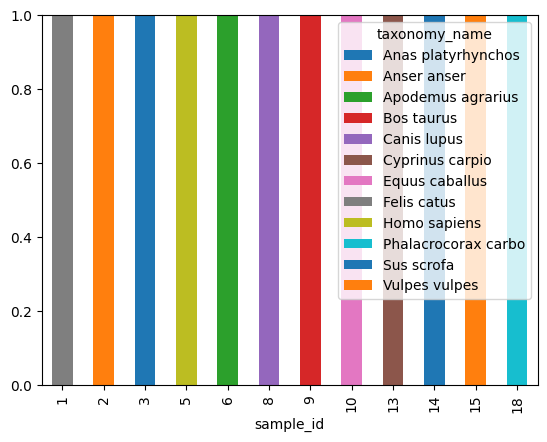

In [55]:
matrix_norm.plot(kind='bar', stacked=True)

# Zadanie 5. 

Biolog w eksperymencie bada próbki środowiskowe w celu badania bioróżnorodności ptaków. Oblicz liczbę wystąpień każdego gatunku ptaka w każdej próbce.

**Uwaga:** za poprawnie rozpoznane kręgowce uznaje się jedynie te rozpoznane z prawdopodobieństwem ponad $97\%$.

In [ ]:
#BIOM MELT DO ŁĄCZENIA
biom.rename(columns={biom.columns[0]: "sample_num"}, inplace=True)
biom_melt = biom.melt(
    id_vars=["sample_num"],    # Kolumna, która ma pozostać bez zmian
    var_name="hash_id",       # Nowa nazwa dla nagłówków kolumn (sekwencji)
    value_name="count"    # Nowa nazwa dla wartości (liczebności)
)

biom_melt.head()

,sample_num,hash_id,count
0,1,cd2f6ab0a17fb7ba634b66b75cfb32dc,92
1,2,cd2f6ab0a17fb7ba634b66b75cfb32dc,96
2,3,cd2f6ab0a17fb7ba634b66b75cfb32dc,35
3,4,cd2f6ab0a17fb7ba634b66b75cfb32dc,126
4,5,cd2f6ab0a17fb7ba634b66b75cfb32dc,170


In [85]:
ptaki = ["Anas platyrhynchos", "Anser anser", "Lyrurus tetrix", "Tetrao urogallus", "Phalacrocorax carbo"]

fru_taxsmpl = tax_smpl[tax_smpl["taxonomy_name"].isin(ptaki)]
fru = fru_taxsmpl[fru_taxsmpl["percentage"] > 97]

In [106]:
fru["taxonomy_name"].nunique()

3

In [ ]:
fru_inbiom = pd.merge(
    biom_melt, 
    fru, 
    left_on=["sample_num", "hash_id"], 
    right_on=["sample_id", "hash_id"]
)

#bez hash id i sample pomiesza łączenie i wyjdzie z 3mln wierszy

In [100]:
fru_inbiom.head()

,sample_num,hash_id,count,index,taxonomy_name,taxonomy_data,percentage,sample_id,site,season,depth,molecule,rep_number,temperature,humidity,particles
0,18,4cdfd0688d020ddf522f55de2e648b6b,80,18,Phalacrocorax carbo,18,99.401426,18,site_1,spring,80.0,RNA,3,17.0,47.0,365.369793
1,15,f5d18f3bd2b6c9b725c5c06ea1d40209,1,15,Anser anser,15,98.672171,15,site_1,spring,50.0,DNA,3,17.0,47.0,716.504763
2,14,bdfeae27d68fd605b9d9374e2c1c4102,1,14,Anas platyrhynchos,14,99.433266,14,site_1,spring,20.0,RNA,3,17.0,47.0,146.664853
3,14,a36ad81546f3d96884518253e34e806e,191,14,Anas platyrhynchos,14,99.578626,14,site_1,spring,20.0,RNA,3,17.0,47.0,146.664853
4,15,b8e640c6d42d87f6ce91fe1c659bf5a0,0,15,Anser anser,15,99.749105,15,site_1,spring,50.0,DNA,3,17.0,47.0,716.504763


In [105]:
fru_inbiom["taxonomy_name"].nunique()

3

In [102]:
fru_stats = fru_inbiom.groupby(["sample_id", "taxonomy_name"])["count"].sum().reset_index()

In [ ]:
fru_stats.head()

,sample_id,taxonomy_name,count
0,14,Anas platyrhynchos,8109
1,15,Anser anser,11653
2,18,Phalacrocorax carbo,14434


pokazują się tylko 3 gatunki ptaków ponieważ pozostałe nie zostały rozpoznane poprawnie (miały poniżej 97% prawdopodobieństwa)

# Zadanie 6.

W próbkach typu rural nie powinnien występować człowiek. Oczyść te próbki z sekwencji przypisanych do człowieka. Następnie ponownie oblicz poznane miary $\alpha-\text{diversity}$ dla tych próbek. Ponownie oceń bioróżnorodność.

**Uwaga:** za poprawnie rozpoznane kręgowce uznaje się jedynie te rozpoznane z prawdopodobieństwem ponad $97\%$.

In [63]:
st_smpl = pd.merge(sites, samples, 
                   left_on="site_name", 
                   right_on="site", 
                   suffixes=("_st", "_smpl"))
st_smpl.head()

,site_name,latitude,longitude,human_activity,sample_id,site,season,depth,molecule,rep_number,temperature,humidity,particles
0,site_1,52.044225,18.228474,urban,1,site_1,spring,20.0,DNA,1,13.0,48.0,487.171474
1,site_1,52.044225,18.228474,urban,2,site_1,spring,20.0,RNA,1,13.0,48.0,561.125523
2,site_1,52.044225,18.228474,urban,3,site_1,spring,50.0,DNA,1,13.0,48.0,315.156923
3,site_1,52.044225,18.228474,urban,5,site_1,spring,80.0,DNA,1,13.0,48.0,282.204666
4,site_1,52.044225,18.228474,urban,6,site_1,spring,80.0,RNA,1,13.0,48.0,487.280159


In [64]:
st_smpl_biom = pd.merge(st_smpl, biom_melt, 
                        left_on="sample_id", 
                        right_on="sample_num", 
                        suffixes=("_stmpl", "_biom"))

st_smpl_biom.head()

,site_name,latitude,longitude,human_activity,sample_id,site,season,depth,molecule,rep_number,temperature,humidity,particles,sample_num,hash_id,count
0,site_1,52.044225,18.228474,urban,1,site_1,spring,20.0,DNA,1,13.0,48.0,487.171474,1,cd2f6ab0a17fb7ba634b66b75cfb32dc,92
1,site_1,52.044225,18.228474,urban,1,site_1,spring,20.0,DNA,1,13.0,48.0,487.171474,1,e2d7606d4577d12f4d8daba49614ef51,1
2,site_1,52.044225,18.228474,urban,1,site_1,spring,20.0,DNA,1,13.0,48.0,487.171474,1,795a06e26ee8d33cacf68eda9a7b0534,76
3,site_1,52.044225,18.228474,urban,1,site_1,spring,20.0,DNA,1,13.0,48.0,487.171474,1,c70d7b3cb1972d94e2f78784d354d014,65
4,site_1,52.044225,18.228474,urban,1,site_1,spring,20.0,DNA,1,13.0,48.0,487.171474,1,87bb0d2a13ff63b63d48f4464ee163a1,20


In [65]:
rural = st_smpl_biom[st_smpl_biom["human_activity"] == "rural"]

In [66]:
whum = tax_full[tax_full["taxonomy_name"] == "Homo sapiens"]
human = whum[whum["percentage"] > 97]
human_hashlist = human["hash_id"].to_list()

In [67]:
rural_clean = rural[~rural["hash_id"].isin(human_hashlist)]
rural_clean.head()

,site_name,latitude,longitude,human_activity,sample_id,site,season,depth,molecule,rep_number,temperature,humidity,particles,sample_num,hash_id,count
913240,site_3,52.816902,22.739079,rural,181,site_3,spring,20.0,DNA,1,17.0,9.0,179.697687,181,cd2f6ab0a17fb7ba634b66b75cfb32dc,265
913242,site_3,52.816902,22.739079,rural,181,site_3,spring,20.0,DNA,1,17.0,9.0,179.697687,181,795a06e26ee8d33cacf68eda9a7b0534,0
913245,site_3,52.816902,22.739079,rural,181,site_3,spring,20.0,DNA,1,17.0,9.0,179.697687,181,191eed68aac33db853c135d04e477c4f,0
913246,site_3,52.816902,22.739079,rural,181,site_3,spring,20.0,DNA,1,17.0,9.0,179.697687,181,4cdfd0688d020ddf522f55de2e648b6b,193
913249,site_3,52.816902,22.739079,rural,181,site_3,spring,20.0,DNA,1,17.0,9.0,179.697687,181,c416ccb2f09a93eba88d3ac09ac93d03,279


# Zadanie 7.

Oceń populację wilka szarego na podstawie dostarczonych danych. Sprawdź jak rozkłada się jego obecność w próbkach *urban* vs *rural* oraz w poszczególnych regionach polski: północny wschód, północny zachód, południowy wschód, południowy zachód.

**Uwaga:** za poprawnie rozpoznane kręgowce uznaje się jedynie te rozpoznane z prawdopodobieństwem ponad $97\%$.

In [68]:
#wilk_inbiom = biom.loc[:, biom.columns.isin(wilk_hashlist)]

In [69]:
#wilk szary - canis lupus
wilk = tax_full[tax_full["taxonomy_name"] == "Canis lupus"]
wilk = wilk[wilk["percentage"] > 97]
wilk_hashlist = wilk["hash_id"].to_list()
#tablica z wilczkami wszystko
woof = st_smpl_biom[st_smpl_biom["hash_id"].isin(wilk_hashlist)]
woof.head()

,site_name,latitude,longitude,human_activity,sample_id,site,season,depth,molecule,rep_number,temperature,humidity,particles,sample_num,hash_id,count
5,site_1,52.044225,18.228474,urban,1,site_1,spring,20.0,DNA,1,13.0,48.0,487.171474,1,191eed68aac33db853c135d04e477c4f,22
14,site_1,52.044225,18.228474,urban,1,site_1,spring,20.0,DNA,1,13.0,48.0,487.171474,1,8e19f270ce3d4ec34010b632531498ce,121
22,site_1,52.044225,18.228474,urban,1,site_1,spring,20.0,DNA,1,13.0,48.0,487.171474,1,e8122406cbf3d2a8674788f81f303dda,143
37,site_1,52.044225,18.228474,urban,1,site_1,spring,20.0,DNA,1,13.0,48.0,487.171474,1,6c6e0130024850c5e2ca764609a49a75,1
44,site_1,52.044225,18.228474,urban,1,site_1,spring,20.0,DNA,1,13.0,48.0,487.171474,1,d6b3a7adee1d766eb04c0b7280bd9139,1


In [70]:
#kierunki
w_ne = (woof["latitude"] > 0) & (woof["longitude"] > 0)
w_nw = (woof["latitude"] > 0) & (woof["longitude"] < 0)
w_se = (woof["latitude"] < 0) & (woof["longitude"] > 0)
w_sw = (woof["latitude"] < 0) & (woof["longitude"] < 0)
#środowisko
w_urban = woof[woof["human_activity"] == "urban"]
w_rural = woof[woof["human_activity"] == "rural"]

In [71]:
w_ne.head()

5     True
14    True
22    True
37    True
44    True
dtype: bool

In [72]:
#środowiska
count_wurban = w_urban["count"].value_counts().sum()
count_wrural = w_rural["count"].value_counts().sum()

#kierunki


In [73]:
r = (count_wurban - count_wrural)
print(f'''w próbkach urban wilk występuje: {count_wurban} razy,
w próbkach rural wilk występuje: {count_wrural} razy,
różnica wynosi {r}, a w próbkach urban wilk występuje częściej''')

w próbkach urban wilk występuje: 144364 razy,
w próbkach rural wilk występuje: 123607 razy,
różnica wynosi 20757, a w próbkach urban wilk występuje częściej


# Zadanie 8.

Sprawdź jak wygląda populacja dzika w Polsce na podstawie dostarczonych próbek. Oceń średnią liczbę dzików na każdym stanowisku w podziale na sezony. Czy można wyciągnąć jakieś wnioski?

In [74]:
#dzik - sus scrofa
dzik = tax_full[tax_full["taxonomy_name"] == "Canis lupus"]
dzik = dzik[dzik["percentage"] > 97]
dzik_hashlist = dzik["hash_id"].to_list()
#tablica z wilczkami wszystko
hrum = st_smpl_biom[st_smpl_biom["hash_id"].isin(dzik_hashlist)]
hrum.head()

,site_name,latitude,longitude,human_activity,sample_id,site,season,depth,molecule,rep_number,temperature,humidity,particles,sample_num,hash_id,count
5,site_1,52.044225,18.228474,urban,1,site_1,spring,20.0,DNA,1,13.0,48.0,487.171474,1,191eed68aac33db853c135d04e477c4f,22
14,site_1,52.044225,18.228474,urban,1,site_1,spring,20.0,DNA,1,13.0,48.0,487.171474,1,8e19f270ce3d4ec34010b632531498ce,121
22,site_1,52.044225,18.228474,urban,1,site_1,spring,20.0,DNA,1,13.0,48.0,487.171474,1,e8122406cbf3d2a8674788f81f303dda,143
37,site_1,52.044225,18.228474,urban,1,site_1,spring,20.0,DNA,1,13.0,48.0,487.171474,1,6c6e0130024850c5e2ca764609a49a75,1
44,site_1,52.044225,18.228474,urban,1,site_1,spring,20.0,DNA,1,13.0,48.0,487.171474,1,d6b3a7adee1d766eb04c0b7280bd9139,1


In [75]:
hrum_st = hrum.groupby("site")["count"].size()
hrum_st.groupby("season")

KeyError: 'season'